In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
animals = ['BS_86','BS_100','BS_119','BS_123','BS_128','BS_131','BS_163','BS_174','BS_111','BS_92']

In [3]:
import re

import numpy as np

_VALID_SEPARATORS = frozenset(' ,\n\t\r')


def _clean_numpy_repr(s: str) -> str:
    s = s.replace('array(', '')
    s = re.sub(r',?\s*dtype=\w+\s*', '', s)
    s = s.replace(')', '')
    return s


def str_to_np(s: str) -> np.ndarray:
    if not isinstance(s, str) or not s.strip():
        raise ValueError("Input must be a non-empty string")
    s = s.strip()
    s = _clean_numpy_repr(s)
    result, pos = _parse(s, 0)
    pos = _skip_separators(s, pos)
    if pos < len(s):
        raise ValueError(
            f"Unexpected trailing content at position {pos}: "
            f"'{s[pos:pos + 20]}{'...' if len(s) - pos > 20 else ''}'"
        )
    return _to_numpy(result)


def _skip_separators(s: str, i: int) -> int:
    while i < len(s) and s[i] in _VALID_SEPARATORS:
        i += 1
    return i


def _parse(s: str, i: int):
    i = _skip_separators(s, i)
    if i >= len(s):
        raise ValueError("Unexpected end of string")
    if s[i] == '[':
        return _parse_list(s, i)
    return _parse_atom(s, i)


def _parse_list(s: str, i: int):
    i += 1
    items = []
    while True:
        i = _skip_separators(s, i)
        if i >= len(s):
            raise ValueError("Unclosed list, missing closing ']'")
        if s[i] == ']':
            return items, i + 1
        if s[i] == '[':
            item, i = _parse_list(s, i)
        else:
            item, i = _parse_atom(s, i)
        items.append(item)


def _parse_atom(s: str, i: int):
    j = i
    while j < len(s) and s[j] not in _VALID_SEPARATORS and s[j] not in '[]':
        j += 1
    if j == i:
        raise ValueError(f"Empty token at position {i}")
    token = s[i:j]
    if token.lower() == 'nan':
        return np.nan, j
    if token == 'True':
        return True, j
    if token == 'False':
        return False, j
    try:
        return float(token), j
    except ValueError:
        raise ValueError(
            f"Invalid token at position {i}: '{token}' is not a valid number, 'nan', 'True', or 'False'"
        )


def _to_numpy(x):
    if not isinstance(x, list):
        return np.array(x)
    if len(x) == 0:
        return np.array([])

    child_is_list = [isinstance(item, list) for item in x]

    if all(child_is_list):
        children = [_to_numpy(item) for item in x]
        shapes = [a.shape for a in children]
        dtypes = [a.dtype for a in children]

        if len(set(dtypes)) > 1:
            raise ValueError(
                "Mixed types across sub-arrays: all sub-arrays must have the same dtype"
            )

        if len(set(shapes)) == 1:
            try:
                return np.array(children)
            except Exception:
                arr = np.empty(len(children), dtype=object)
                for i, c in enumerate(children):
                    arr[i] = c
                return arr
        else:
            arr = np.empty(len(children), dtype=object)
            for i, c in enumerate(children):
                arr[i] = c
            return arr

    if not any(child_is_list):
        types = {type(v) for v in x}
        if types == {bool}:
            return np.array(x, dtype=bool)
        if types <= {float}:
            return np.array(x, dtype=float)
        raise ValueError(
            "Mixed types in array: cannot mix booleans with numbers"
        )

    raise ValueError(
        "Mixed content in list: some items are arrays and some are scalars"
    )


In [4]:
class TrialInterval:
    _startTimeSamples = 0
    _endTimeSamples = 0
    _isStartTimeRelToResponse = True
    _isEndTimeRelToResponse = True
    _averageLickDelay = 0.2 * 30000

    def __init__(self,start,end,startresp,endresp):
        self._startTimeSamples = start
        self._endTimeSamples = end
        self._isStartTimeRelToResponse = startresp
        self._isEndTimeRelToResponse = endresp

    def _CalculateAvgLickDelay(self,sessionfile):
        go_responses = np.array(sessionfile.trials.response)[sessionfile.trials.go]
        go_starts = np.array(sessionfile.trials.starts)[sessionfile.trials.go]
        self._averageLickDelay = np.nanmean(go_responses - go_starts)

    def _ToTimestamp(self,sessionfile,trial):
        starttime = sessionfile.trials.starts[trial]
        if self._isStartTimeRelToResponse:
            starttime = sessionfile.trials.response[trial]
            if np.isnan(starttime):
                starttime = sessionfile.trials.starts[trial] + self._averageLickDelay
        starttime = starttime + self._startTimeSamples

        endtime = sessionfile.trials.starts[trial]
        if self._isEndTimeRelToResponse:
            endtime = sessionfile.trials.response[trial]
            if np.isnan(endtime):
                endtime = sessionfile.trials.starts[trial] + self._averageLickDelay
        endtime = endtime + self._endTimeSamples

        return [starttime,endtime]

    def _ToString(self):
        return f"Interval has start {self._startTimeSamples}, end {self._startTimeSamples}. startresp {self._isStartTimeRelToResponse} and endresp {self._isEndTimeRelToResponse}"

# def statisticalComparison(sessionfile,clust,preCondition,postCondition):
#     preInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
#     postInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
    
#     allConditions = ilep.getAllConditions(sessionfile,clust)
#     preTrials = allConditions[preCondition].trials
#     postTrials = allConditions[postCondition].trials
        
#     preTrialRates = np.full_like(preTrials,np.nan,dtype='float')
#     postTrialRates = np.full_like(postTrials,np.nan,dtype='float')    
#     for idx,trial in enumerate(preTrials):
#         start,end = preInterval._ToTimestamp(sessionfile,trial)
#         spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
#         preTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
#     for idx,trial in enumerate(postTrials):
#         start,end = postInterval._ToTimestamp(sessionfile,trial)
#         spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
#         postTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
        
#     pvalue_inc = mannwhitneyu(preTrialRates,postTrialRates,alternative='less').pvalue
#     pvalue_dec = mannwhitneyu(preTrialRates,postTrialRates,alternative='greater').pvalue
#     if pvalue_inc <= 0.05:# and np.median(postTrialRates) > np.median(preTrialRates):
#         label = 'increased'
#         pvalue = pvalue_inc
#     elif pvalue_dec <= 0.05:# and np.median(postTrialRates) < np.median(preTrialRates):
#         label = 'decreased'
#         pvalue = pvalue_dec
#     else:
#         label = 'unchanged'
#         pvalue = np.min(pvalue_inc,pvalue_dec)
#     return label,pvalue

def statisticalComparison(sessionfile,clust,preCondition,postCondition,preInterval,postInterval,iterations=5000,sample_percent=0.5,pthresh=0.95,modthresh=0.1):
    if pthresh < 0.5:
        raise Exception('pthresh cannot be less than 50%!')
    
    preInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
    postInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
    
    allConditions = ilep.getAllConditions(sessionfile,clust)
    preTrials = allConditions[preCondition].trials
    postTrials = allConditions[postCondition].trials
    
    if preCondition == postCondition:
        paired=True
    else:
        paired=False
    
    preTrialRates = np.full_like(preTrials,np.nan,dtype='float')
    postTrialRates = np.full_like(postTrials,np.nan,dtype='float')
    
    for idx,trial in enumerate(preTrials):
        start,end = preInterval._ToTimestamp(sessionfile,trial)
        spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
        preTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
        
    for idx,trial in enumerate(postTrials):
        start,end = postInterval._ToTimestamp(sessionfile,trial)
        spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
        postTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
    
    increased=0
    decreased=0
    unchanged=0
    
    for i in range(iterations):
        if paired and len(preTrialRates) != len(preTrialRates):
            raise Exception('Non-equal length paired comparison')
        if paired:
            raise Exception('Paired comparison is not yet implemented')
        else:
            preIdxs = range(len(preTrialRates))
            postIdxs = range(len(postTrialRates))
            preIdxs = np.random.permutation(preIdxs)
            postIdxs = np.random.permutation(postIdxs)
            maxIdx = int(sample_percent*min(len(preIdxs),len(postIdxs)))
            preIdxs = preIdxs[range(maxIdx)]
            postIdxs = postIdxs[range(maxIdx)]
            
        preTrialsToCompare = preTrialRates[preIdxs]
        postTrialsToCompare = postTrialRates[postIdxs]
        
        deltaTrialMean = np.mean(postTrialsToCompare - preTrialsToCompare)
        
        if deltaTrialMean >= modthresh:
            increased+=1
        elif deltaTrialMean <= -modthresh:
            decreased+=1
        else:
            unchanged+=1
            
    p_increased = increased / (increased+decreased+unchanged)
    p_decreased = decreased / (increased+decreased+unchanged)
    p_unchanged = unchanged / (increased+decreased+unchanged)
    
    print(f"inc: {p_increased}, dec: {p_decreased}, unch: {p_unchanged}")
    
    if p_increased >= pthresh:
        label='increased'
        pval = 1-p_increased
    elif p_decreased >= pthresh:
        label='decreased'
        pval = 1-p_decreased
    elif p_unchanged >= pthresh:
        label='unchanged'
        pval = 1-p_unchanged
    else:
        label='inconclusive'
        pval=1-np.max([p_increased,p_decreased,p_unchanged])
    return label,pval

In [5]:
#this function calculates pval for one cluster(one cell)
def calculate_NCR_CR_pval(sessionfile,clust):

    #convert window(100ms) in samples
    sessionfile.meta.fs #30000 samples / second from blackrock
    window = sessionfile.meta.fs * 0.1
    trials_to_use = sessionfile.trim[clust].trimmed_trials

    #create array for stimulus period
    #tone play start time
    onset_window_start_time = np.zeros(len(trials_to_use))
    for idx, trial in enumerate(trials_to_use):
        onset_window_start_time[idx] = sessionfile.trials.starts[trial]

    #tone play end time
    onset_window_end_time = onset_window_start_time + window
    #offset window start time
    offset_window_start_time = onset_window_end_time
    #offset window end time
    offset_window_end_time = offset_window_start_time + window
    #stimulus array
    stimulus_array = np.zeros([len(onset_window_start_time),2,2])
    for i in range(len(onset_window_start_time)):
        stimulus_array[i] = [[onset_window_start_time[i],onset_window_end_time[i]],
                             [offset_window_start_time[i],offset_window_end_time[i]]
                            ]

    #create array for baseline period
    base_window1_start = onset_window_start_time - 3*window
    base_window1_end = onset_window_start_time - 2*window
    base_window2_start = base_window1_end
    base_window2_end = onset_window_start_time - 1*window
    base_window3_start = base_window2_end
    base_window3_end = onset_window_start_time

    baseline_array = np.zeros([len(base_window1_start),3,2])
    for i in range(len(onset_window_start_time)):
        baseline_array[i] = [[base_window1_start[i],base_window1_end[i]],
                             [base_window2_start[i],base_window2_end[i]],
                             [base_window3_start[i],base_window3_end[i]],
                            ]

    #evaluate spike count within stimulus window
    spikecounts_stimuluswindow = np.zeros((len(onset_window_start_time),2))

    for idx, t in enumerate(stimulus_array):
        #print(t[0][0])

        #spike count from onset window
        spikecount_onsetwindow = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[0][0],endtime=t[0][1]))

        #spike count from offset window
        spikecount_offsetwindow = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[1][0],endtime=t[1][1]))

        spikecounts_stimuluswindow[idx][0]=spikecount_onsetwindow
        spikecounts_stimuluswindow[idx][1]=spikecount_offsetwindow

    #evaluate spike count within baseline window
    spikecounts_basewindow = np.zeros((len(onset_window_start_time),3))

    for idx, t in enumerate(baseline_array):
        #print(t[0][0])

        #spike count from window1
        spikecount_base_window1 = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[0][0],endtime=t[0][1]))

        #spike count from window2
        spikecount_base_window2 = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[1][0],endtime=t[1][1]))

        #spike count from window3
        spikecount_base_window3 = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[2][0],endtime=t[2][1]))

        spikecounts_basewindow[idx][0]=spikecount_base_window1
        spikecounts_basewindow[idx][1]=spikecount_base_window2
        spikecounts_basewindow[idx][2]=spikecount_base_window3

    ###### CODE BELOW HERE SHOULD LOOP 5000 TIMES 
    iterations = 5000
    #spikecounts_diff_mean_arr = []

    CR_evok_appear=0
    CR_sup_appear=0
    NCR_appear=0

    for i in range(iterations):

        #1.subsampled 90% of the spike count changes from baseline,
        #2.calculated the mean of these values, repeated this process 5000 times 

        #1.
        #subsampled 90% trials
        trials = range(len(spikecounts_stimuluswindow))
        trials_perm = np.random.permutation(trials)
        trials_subsamp = trials_perm[range(int(0.9*len(trials_perm)))]

        #calculate spike count changes from baseline in the subsample
        spikecounts_diff = []
        for trial_idx in trials_subsamp:
            random_stimulus = spikecounts_stimuluswindow[trial_idx][np.random.randint(2)]
            random_base = spikecounts_basewindow[trial_idx][np.random.randint(3)]
            spikecounts_diff.append(random_stimulus-random_base)

        #2. 
        #calculate the mean of the spike counts diff  
        spikecounts_diff_mean = np.mean(spikecounts_diff)
        #calculate the # of appearance in each categotiry in 5000 iterations
        if spikecounts_diff_mean > 0.1:
            CR_evok_appear+=1
        elif spikecounts_diff_mean < -0.1:
            CR_sup_appear+=1
        else:
            NCR_appear+=1
            
    p_value_evoked = CR_evok_appear/(iterations)
    p_value_suppressed = CR_sup_appear/(iterations)
    p_value_NCR = NCR_appear/(iterations)
    return p_value_evoked, p_value_suppressed, p_value_NCR

In [6]:
def get_response_times_with_default(sessionfile):
    response_times_in_trial = (sessionfile.trials.response-sessionfile.trials.starts)
    default_response_time = np.nanmedian(response_times_in_trial)

    response_times = sessionfile.trials.response
    nogo_trials = np.isnan(response_times)
    response_times[nogo_trials] = sessionfile.trials.starts[nogo_trials]+default_response_time
    return response_times

In [7]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3b.csv'))

In [8]:
df

,Unnamed: 0,animal,session,phase,cluster,FR modulation,trials,spike times,on trials,off trials
0,0,BS_111,BS_111_10_opto_AC.pickle,post late,54,3.596244,[ 1 3 4 6 7 8 9 11 12 13 16 ...,"[array([187.13333333]) array([], dtype=float64...",[ True True True True True True True Tr...,[False False False False False False False Fal...
1,1,BS_92,BS_92_5_opto_AC.pickle,post late,247,5.682303,[ 0 1 4 5 6 9 11 12 13 15 17 ...,"[array([], dtype=float64) array([], dtype=floa...",[ True True True True True True True Tr...,[False False False False False False False Fal...


In [9]:
def plot_raster_PSTH_opto(row,ax1,ax2,Figure_start_time_ms=-250,Figure_end_time_ms=1000,xtickstouse=[0,500,1000],align_to_choice=False,switch_cond='NA',limitToUse=None):
    buffer = 250

    trialsToPlot = str_to_np(row['trials'])
    trialSpikes = str_to_np(row['spike times'])
    trials_on_mask = str_to_np(row['on trials'])
    trials_off_mask = str_to_np(row['off trials'])

    trials_on = trialsToPlot[trials_on_mask].astype(int)
    trials_off = trialsToPlot[trials_off_mask].astype(int)
    spikes_on = trialSpikes[trials_on_mask]
    spikes_off = trialSpikes[trials_off_mask]

    num_on = len(trials_on+1)
    num_off = len(trials_off+1)


    #Plot Raster
    for idx,trial in enumerate(trialsToPlot):
        if idx < num_on:
            color_to_use = LASER_COLOR
        else:
            color_to_use = 'k'
        ax1.scatter(trialSpikes[idx],np.ones_like(trialSpikes[idx])*idx,color=color_to_use,s=5,marker='o',lw=0,zorder=0)


    ax1.set_yticks([num_on/2,num_on+num_off/2])
    ax1.set_yticklabels(['ON','OFF'])
    colors = [LASER_COLOR,'k']
    [t.set_color(colors[idx]) for idx,t in enumerate(ax1.yaxis.get_ticklabels())]

    #Plot PSTH - ON
    trialSpikesOn = trialSpikes[range(num_on)]
    color_to_use = LASER_COLOR
    starttime = Figure_start_time_ms
    endtime = Figure_end_time_ms
    xrange = np.linspace(starttime,endtime,num=1000)
    numSplits = min(10,len(trialSpikesOn))
    if numSplits < 2:
        return False,[] ### Return a failure
    FR = np.full((numSplits,len(xrange)),np.nan)
    kf = KFold(n_splits=numSplits)
    for idx,(_,train_index) in enumerate(kf.split(trialSpikesOn)):
        PSTHspikes = np.concatenate(trialSpikesOn[train_index])
        if len(PSTHspikes) == 0:
            FR[idx,:] = np.zeros(len(xrange))
            continue
        bw = 0.05
        KDE = gaussian_kde(PSTHspikes,bw_method=bw)
        FR[idx,:] = KDE.evaluate(xrange)
        FR[idx,:] = FR[idx,:] * len(PSTHspikes) / len(train_index) * 1000 #1000 is conversion to s/s because units are all in ms for this plot
    avg_FR = np.mean(FR,axis=0)
    sem_FR = sem(FR,axis=0)
    ax2.plot(xrange,avg_FR,lw=2,color=color_to_use)
    ax2.fill_between(xrange,avg_FR-sem_FR,avg_FR+sem_FR,color=color_to_use,alpha=0.05,zorder=-10,lw=0)
    max_FR_on = np.max(avg_FR+sem_FR) * 1.1
    
    #Plot PSTH - OFF
    trialSpikesOff = trialSpikes[range(num_on,num_on+num_off)]
    color_to_use = 'k'
    starttime = Figure_start_time_ms
    endtime = Figure_end_time_ms
    xrange = np.linspace(starttime,endtime,num=1000)
    numSplits = min(10,len(trialSpikesOff))
    if numSplits < 2:
        return False,[]
    FR = np.full((numSplits,len(xrange)),np.nan)
    kf = KFold(n_splits=numSplits)
    for idx,(_,train_index) in enumerate(kf.split(trialSpikesOff)):
        PSTHspikes = np.concatenate(trialSpikesOff[train_index])
        if len(PSTHspikes) == 0:
            FR[idx,:] = np.zeros(len(xrange))
            continue
        bw = 0.05 
        KDE = gaussian_kde(PSTHspikes,bw_method=bw)
        FR[idx,:] = KDE.evaluate(xrange)
        FR[idx,:] = FR[idx,:] * len(PSTHspikes) / len(train_index) * 1000 #1000 is conversion to s/s because units are all in ms for this plot
    avg_FR = np.mean(FR,axis=0)
    sem_FR = sem(FR,axis=0)
    ax2.plot(xrange,avg_FR,lw=2,color=color_to_use)
    ax2.fill_between(xrange,avg_FR-sem_FR,avg_FR+sem_FR,color=color_to_use,alpha=0.05,zorder=-10,lw=0)
    max_FR_off = np.max(avg_FR+sem_FR) * 1.1

    #PSTH Limits
    if limitToUse is None:
        max_FR_value = max(max_FR_on,max_FR_off)
        sequence_of_possible_axis_limits = np.array([1,2,4,6,8,10,12,16,20,30,40,50,60,80,100,120,140,150,160,180,200])
        idx_of_okay_limits = np.greater_equal(sequence_of_possible_axis_limits,max_FR_value)
        valid_limits = sequence_of_possible_axis_limits[idx_of_okay_limits]
        limit = np.min(valid_limits)
    else:
        limit  = limitToUse

    ylab1 = ax1.set_ylabel('Trial')
    
    ax2.set_ylim([0,limit])
    ax2.set_yticks([0,limit/2,limit])
    ax2.set_yticklabels(['0',str(int(limit/2)),str(limit)])
    ylab = ax2.set_ylabel('Firing rate (spikes/s)')
    
    ### X limits
    ax1.set_xlim([starttime,endtime])
    ax1.set_xticks(np.array(xtickstouse))
    ax1.set_xticklabels(np.array(xtickstouse))
    
    ax2.set_xlim([starttime,endtime])
    ax2.set_xticks(np.array(xtickstouse))
    ax2.set_xticklabels(np.array(xtickstouse))
    if align_to_choice:
        xlab1 = ax1.set_xlabel('Time (ms)')
        xlab = ax2.set_xlabel('Time (ms)')
    else:
        xlab1 = ax1.set_xlabel('Time (ms)')
        xlab = ax2.set_xlabel('Time (ms)')
    
    ### Tone bar
    ax1.set_ylim(ax1.get_ylim())
    if not align_to_choice:
        ylim = ax1.get_ylim()[1] + 0.1*(ax1.get_ylim()[1]-ax1.get_ylim()[0])
        tonebar = ax1.plot([0,100],[ylim]*2,c=LASER_COLOR,lw=1.5,clip_on=False)
    
    ################################################################

    for axis in ['bottom','left']:
        ax1.spines[axis].set_linewidth(1.5)
        ax2.spines[axis].set_linewidth(1.5)
    ax1.tick_params(width=1.5)
    ax2.tick_params(width=1.5)
    for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
        ax1.get_xticklabels() + ax1.get_yticklabels()):
        item.set_fontsize(20)
    for item in ([ax2.title, ax2.xaxis.label, ax2.yaxis.label] +
        ax2.get_xticklabels() + ax2.get_yticklabels()):
        item.set_fontsize(20)
    
    ttl = ax1.set_title('')
    artists = [ylab,xlab,ttl]
    plt.show()
    return True,artists

BS_111_10_opto_AC.pickle 54


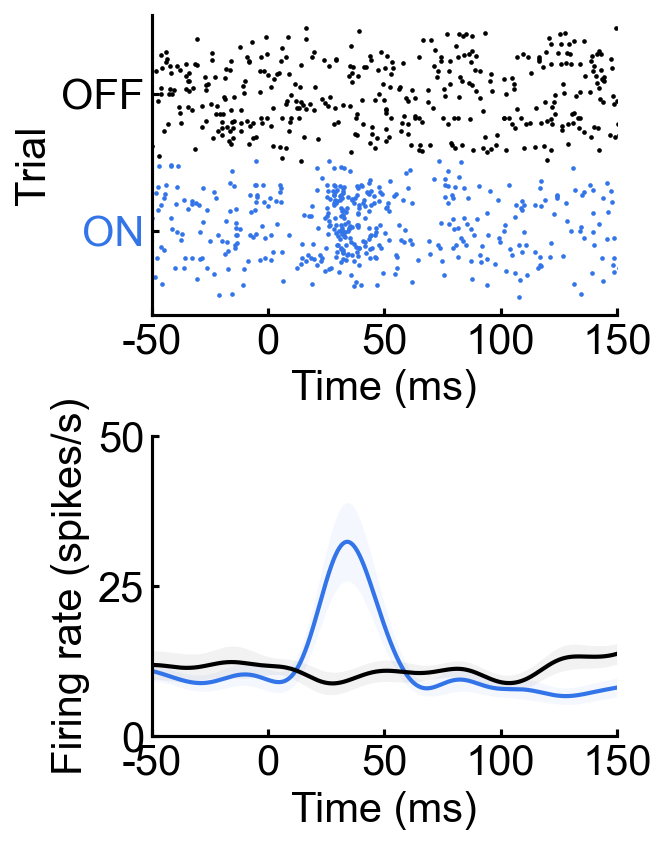

BS_92_5_opto_AC.pickle 247


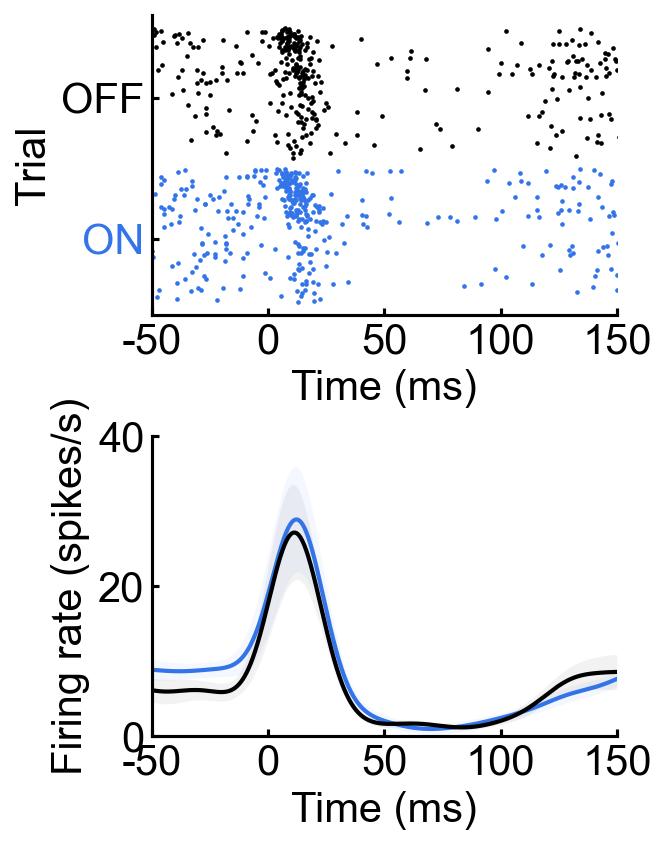

In [10]:
for row in df.iloc():
    limitToUse = None#30
    
    skip = True

    session = row['session']
    clust = row['cluster']
    phase = row['phase']
    FRmod = row['FR modulation']
    fig_title = ''
    
    if session == 'BS_111_10_opto_AC.pickle' and clust in [54]:
        fig_title = 'NCR'
        skip = False
    if session == 'BS_92_5_opto_AC.pickle' and clust in [247]:
        fig_title = 'CR'
        skip = False

    if skip:
        continue

    plt.close('all')

    fig = plt.figure(figsize=(4,6.25))
    gs = fig.add_gridspec(2,1,height_ratios=[1,1],hspace=0.4)
    ax3 = plt.subplot(gs[0,0])#Raster
    ax4 = plt.subplot(gs[1,0],sharex=ax3)
    
    success,artists = plot_raster_PSTH_opto(row,ax3,ax4,limitToUse=limitToUse,Figure_start_time_ms=-50,Figure_end_time_ms=150,xtickstouse=[-50,0,50,100,150])
    if not success:
        continue
    
    fig.savefig(os.path.join('..','..','Figures',f'Figure 3b {fig_title}.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')